# Stats Model

Shows revenue and health stats by vehicle model (overall and per model).

- CSV file: final_dataset_for_electiccar_2.csv
- Use the button to refresh results.

In [ ]:
import pandas as pd
from pathlib import Path
import panel as pn
import plotly.express as px

pn.extension(sizing_mode="stretch_width")

DATA_PATH = Path("final_dataset_for_electiccar_2.csv")

df_raw = pd.read_csv(DATA_PATH)

rename_map = {
    "driver id": "driver_id",
    "car id": "car_id",
    "drive name": "drive_name",
    "city": "city",
    "vechicle type": "vehicle_type",
    "vechicle age": "vehicle_age",
    "battery capacity(kw)": "battery_capacity_kw",
    "total km driven": "total_km_driven",
    "current charge percentage": "current_charge_percentage",
    "estimated rangekm": "estimated_rangekm",
    "batery health": "battery_health",
    "vechicle-status": "vehicle_status",
    "average energy per km kwh": "average_energy_per_km_kwh",
    "charging cost": "charging_cost",
    "total maintanace cost": "total_maintenance_cost",
    "max speed": "max_speed",
    "gross revenue": "gross_revenue",
    "driver earnings": "driver_earnings"
}

df = df_raw.rename(columns=rename_map)
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

df.head()

,driver_id,car_id,drive_name,city,vehicle_type,vehicle_age,battery_capacity_kw,total_km_driven,current_charge_percentage,estimated_rangekm,battery_health,vehicle_status,average_energy_per_km_kwh,charging_cost,total_maintenance_cost,max_speed,gross_revenue,driver_earnings
0,1,100001,Driver_1,Chennai,Sedan,6.1,40,59686.6,76.3,175.4,96.8,Active,0.174,3157.22,6227.34,120,429016.47,175021.90
1,2,100002,Driver_2,Bangalore,Mini EV,2.2,75,73156.7,88.2,365.5,74.8,Maintenance,0.181,2031.13,32756.08,140,126657.71,65099.30
2,3,100003,Driver_3,Hyderabad,Hatchback,5.0,30,183784.3,58.3,88.3,81.4,Inactive,0.198,1819.30,39736.81,140,483014.11,295301.09
3,4,100004,Driver_4,Chennai,SUV,6.3,30,214552.8,88.0,176.0,83.6,Maintenance,0.150,1231.94,28515.04,100,506848.25,228761.70
4,5,100005,Driver_5,Bangalore,SUV,4.0,50,247433.2,67.6,204.8,90.5,Active,0.165,1530.72,12442.59,140,99641.45,67152.44


In [ ]:
vehicle_types = sorted(df["vehicle_type"].dropna().unique().tolist())
vehicle_types = ["All"] + vehicle_types

type_select = pn.widgets.Select(name="Vehicle model", options=vehicle_types)
stats_button = pn.widgets.Button(name="See stats", button_type="primary")

summary_pane = pn.pane.Markdown("Ready.")
table_pane = pn.pane.DataFrame(width=900, height=320)
chart_pane = pn.pane.Plotly(height=360)

def build_stats(df_filtered):
    summary = {
        "total_revenue": df_filtered["gross_revenue"].sum(),
        "avg_revenue": df_filtered["gross_revenue"].mean(),
        "total_km": df_filtered["total_km_driven"].sum(),
        "avg_battery_health": df_filtered["battery_health"].mean(),
        "total_maintenance_cost": df_filtered["total_maintenance_cost"].sum(),
    }

    grouped = (
        df_filtered
        .groupby("vehicle_type")
        .agg(
            cars=("car_id", "nunique"),
            total_revenue=("gross_revenue", "sum"),
            avg_revenue=("gross_revenue", "mean"),
            total_km=("total_km_driven", "sum"),
            avg_battery_health=("battery_health", "mean"),
            total_maintenance_cost=("total_maintenance_cost", "sum"),
        )
        .reset_index()
        .sort_values(by="total_revenue", ascending=False)
    )

    return summary, grouped

def build_chart(grouped):
    fig = px.bar(
        grouped,
        x="vehicle_type",
        y="total_revenue",
        text="total_revenue",
        title="Total Revenue by Vehicle Model"
    )
    fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")
    fig.update_layout(yaxis_title="Total revenue", xaxis_title="Vehicle model", height=360)
    return fig

def on_stats_click(event):
    if type_select.value == "All":
        df_filtered = df
    else:
        df_filtered = df[df["vehicle_type"] == type_select.value]

    summary, grouped = build_stats(df_filtered)

    summary_pane.object = (
        f"**Total revenue:** {summary['total_revenue']:.2f}\n"
        f"**Average revenue:** {summary['avg_revenue']:.2f}\n"
        f"**Total km driven:** {summary['total_km']:.2f}\n"
        f"**Average battery health:** {summary['avg_battery_health']:.2f}\n"
        f"**Total maintenance cost:** {summary['total_maintenance_cost']:.2f}"
    )

    table_pane.object = grouped
    chart_pane.object = build_chart(grouped)

stats_button.on_click(on_stats_click)

# Render an initial chart without requiring a button click.
initial_summary, initial_grouped = build_stats(df)
summary_pane.object = (
    f"**Total revenue:** {initial_summary['total_revenue']:.2f}\n"
    f"**Average revenue:** {initial_summary['avg_revenue']:.2f}\n"
    f"**Total km driven:** {initial_summary['total_km']:.2f}\n"
    f"**Average battery health:** {initial_summary['avg_battery_health']:.2f}\n"
    f"**Total maintenance cost:** {initial_summary['total_maintenance_cost']:.2f}"
)
table_pane.object = initial_grouped
chart_pane.object = build_chart(initial_grouped)

dashboard = pn.Column(
    pn.pane.Markdown("## Revenue and Health Stats"),
    pn.Row(type_select, stats_button),
    summary_pane,
    chart_pane,
    table_pane,
    sizing_mode="stretch_width"
)

dashboard

BokehModel(combine_events=True, render_bundle={'docs_json': {'12e87b39-e570-4aa2-9f49-a36c3ba03eaa': {'version…

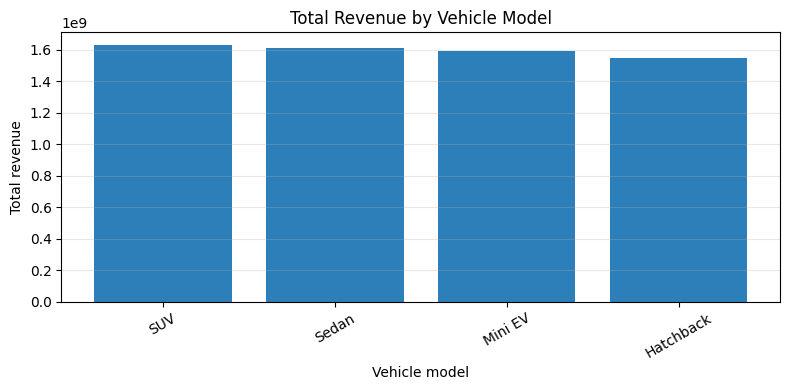

In [3]:
import matplotlib.pyplot as plt

_, grouped = build_stats(df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(grouped["vehicle_type"], grouped["total_revenue"], color="#2c7fb8")
ax.set_title("Total Revenue by Vehicle Model")
ax.set_xlabel("Vehicle model")
ax.set_ylabel("Total revenue")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()